In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [17]:
# Download stock data
data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

C:\Users\Lenovo\anaconda3\lib\site-packages\yfinance\scrapers\history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed


In [18]:
# Display first rows
print(data.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630653  72.389273  71.406681  71.563221  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000
2020-01-08  73.017853  73.318893  71.565636  71.565636  132079200


In [19]:
# Keep required columns
data = data[['Open', 'High', 'Low', 'Volume', 'Close']]

# Create target column (Next Day Close Price)
data['Target_Close'] = data['Close'].shift(-1)

# Remove missing values
data.dropna(inplace=True)


In [20]:
# Features (Input)
X = data[['Open', 'High', 'Low', 'Volume']]

# Target (Output)
y = data['Target_Close']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [21]:
# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [22]:
# Predict on test data
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 2.3319146234617008
R2 Score: 0.9852342679369243


In [23]:
# Predict next day's closing price
latest_data = X.iloc[-1:]

next_day_prediction = model.predict(latest_data)

print("\nPredicted Next Day Close Price:")
print(next_day_prediction[0])


Predicted Next Day Close Price:
250.33863274284988


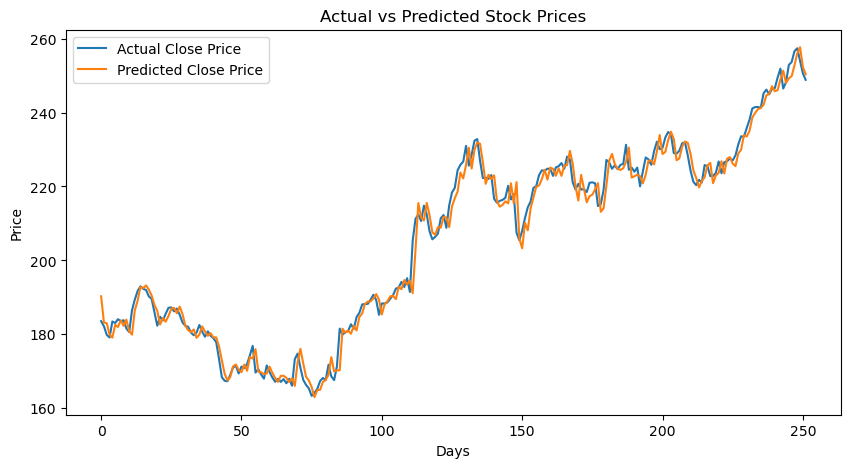

In [24]:
# Plot Actual vs Predicted Prices
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Close Price')
plt.plot(predictions, label='Predicted Close Price')

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()